# Localization at Unseen Positions & Localization Baselines (Task A2: R2.1, R2.2)

Response to Reviewer 1's request to evaluate localization on positions not present
during training, report physical error in metres, and compare against classic
RSSI localization baselines (trilateration, fingerprinting, nearest-centroid).

- **R2.1** — coordinate regression (free (x,y) and ring-constrained angle variants),
  evaluated under two protocols: **LOPO** (leave-one-point-out — the held-out
  *position* is never seen; the real interpolation test) and **LOAO**
  (leave-one-antenna-out — positions are all seen, only the antenna hardware is held
  out; comparable to the classification localization error of 3.32 m from Task A1's F5).
- **R2.2** — four training-light/training-free localization baselines under the same
  two protocols: nearest centroid, weighted centroid localization (WCL), log-distance
  trilateration, and KNN fingerprinting (the existing classifier, reinterpreted in metres).

Builds on `src/eval_protocol.py` (same module as the other notebooks). All CIs are
session-level cluster bootstraps (2000 iterations, seed 0), matching Task A1's
convention.

## 1. Imports & Configuration

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import eval_protocol as ep

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 17,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 320,
    'savefig.dpi': 320,
})

REPO_ROOT = ep._find_repo_root()
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = REPO_ROOT / "figures"
INTERNAL_FIGURES_DIR = FIGURES_DIR / "internal"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
INTERNAL_FIGURES_DIR.mkdir(exist_ok=True)

## 2. Unit Tests (acceptance check #2)

`point_distance_m` is the chord distance on the R=11m ring; every localization error in
this notebook and in `src/eval_protocol.py` is built from the same `POINT_RADIUS_M`/
`point_xy_m`/`point_distance_m` constants and functions.

In [2]:
assert abs(ep.point_distance_m(1, 2) - 8.42) < 0.01, ep.point_distance_m(1, 2)
assert abs(ep.point_distance_m(1, 5) - 22.0) < 1e-9, ep.point_distance_m(1, 5)
assert abs(ep.RANDOM_GUESS_ERROR_M - 14.0) < 0.1, ep.RANDOM_GUESS_ERROR_M
print(f"point_distance_m(1, 2) = {ep.point_distance_m(1, 2):.3f} m  (adjacent points)")
print(f"point_distance_m(1, 5) = {ep.point_distance_m(1, 5):.3f} m  (opposite points)")
print(f"Random-guess reference error on the ring: 4R/pi = {ep.RANDOM_GUESS_ERROR_M:.3f} m")
print("Unit tests passed.")

point_distance_m(1, 2) = 8.419 m  (adjacent points)
point_distance_m(1, 5) = 22.000 m  (opposite points)
Random-guess reference error on the ring: 4R/pi = 14.006 m
Unit tests passed.


## 3. Load Dataset & Sensor-Direction Diagnostic

In [3]:
raw = ep.load_raw()
dataset, info = ep.build_dataset(raw, freq="5s")
dataset = ep.add_fe(dataset)
sub = dataset[dataset["attack"] == 1].reset_index(drop=True)

y_point = sub["point"].to_numpy()
y_xy = np.array([ep.point_xy_m(int(p)) for p in y_point])
sessions = sub["session"].to_numpy()

print(f"Attack rows: {len(sub)}  |  Attack sessions: {sub['session'].nunique()}")
print(f"Point coordinates (AP at origin, metres): {[ep.point_xy_m(i) for i in range(1, 9)]}")

Attack rows: 571  |  Attack sessions: 48
Point coordinates (AP at origin, metres): [(np.float64(11.0), np.float64(0.0)), (np.float64(7.778174593052023), np.float64(7.778174593052022)), (np.float64(6.735557395310443e-16), np.float64(11.0)), (np.float64(-7.778174593052022), np.float64(7.778174593052023)), (np.float64(-11.0), np.float64(1.3471114790620886e-15)), (np.float64(-7.778174593052024), np.float64(-7.778174593052022)), (np.float64(-2.0206672185931327e-15), np.float64(-11.0)), (np.float64(7.778174593052021), np.float64(-7.778174593052024))]


**Sensor-position mapping is inferred from data**, not from the author's recollection
(which could not be confirmed — see `eval_protocol.sensor_mapping_scores()`).
`eval_protocol.SENSOR_POSITIONS` is set to the best of the 24 permutations of
`sensor_1..4 -> {E, N, W, S}`, scored by the mean Pearson correlation between median
attack RSSI and `-log10(distance)` from the attack point to each candidate sensor
position (higher = more consistent with a simple log-distance path-loss model).
`SENSOR_POSITIONS_CONFIRMED` stays `False`: this is the best-scoring permutation, not
an independently confirmed ground truth. R2.2(b) WCL and R2.2(c) trilateration are the
only things that depend on it.

In [4]:
print("SENSOR_POSITIONS (inferred from data):", ep.SENSOR_POSITIONS)
print("SENSOR_POSITIONS_SOURCE:", ep.SENSOR_POSITIONS_SOURCE, "| CONFIRMED:", ep.SENSOR_POSITIONS_CONFIRMED)
print()
diag = ep.diagnostic_sensor_direction_rssi(dataset)
print("Median attack-RSSI per point per sensor (dBm) — axis points are 1=E, 3=N, 5=W, 7=S:")
diag

SENSOR_POSITIONS (inferred from data): {'s1': (0.0, 6.0), 's2': (0.0, -6.0), 's3': (6.0, 0.0), 's4': (-6.0, 0.0)}
SENSOR_POSITIONS_SOURCE: inferred_from_data | CONFIRMED: False

Median attack-RSSI per point per sensor (dBm) — axis points are 1=E, 3=N, 5=W, 7=S:


,s1,s2,s3,s4
point,,,,
1,-84.0,-80.0,-69.0,-87.0
2,-71.0,-70.0,-72.0,-77.0
3,-69.0,-67.0,-76.0,-76.0
4,-68.0,-73.5,-68.0,-71.0
5,-67.0,-84.0,-68.5,-74.0
6,-83.0,-72.0,-69.0,-70.0
7,-75.0,-68.0,-77.0,-74.0
8,-77.0,-68.0,-71.0,-83.0


In [5]:
mapping_scores = ep.sensor_mapping_scores(raw)
mapping_scores.to_csv(RESULTS_DIR / "sensor_mapping_scores.csv", index=False)

print("All 24 sensor_1..4 -> {E,N,W,S} permutations, scored by mean corr(median attack RSSI, -log10 distance):")
print("Top 6:")
print(mapping_scores.head(6).to_string(index=False))
print()
print("Provisional mapping used before this fix (WNES = s1=W,s2=N,s3=E,s4=S):")
print(mapping_scores[mapping_scores.mapping == "WNES"].to_string(index=False))
print("Author's recollection (EWNS = s1=E,s2=W,s3=N,s4=S):")
print(mapping_scores[mapping_scores.mapping == "EWNS"].to_string(index=False))

All 24 sensor_1..4 -> {E,N,W,S} permutations, scored by mean corr(median attack RSSI, -log10 distance):
Top 6:
mapping  score_all  score_omni
   NSEW   0.478996    0.450103
   NESW   0.392815    0.375020
   NEWS   0.370557    0.324045
   ESNW   0.175988    0.137229
   NSWE   0.158894    0.147311
   WENS   0.152722    0.024759

Provisional mapping used before this fix (WNES = s1=W,s2=N,s3=E,s4=S):
mapping  score_all  score_omni
   WNES   0.118516    0.074455
Author's recollection (EWNS = s1=E,s2=W,s3=N,s4=S):
mapping  score_all  score_omni
   EWNS  -0.201217   -0.209919


## 4. R2.1 — Coordinate Regression, Evaluated on Unseen Positions

Rows: attack only. Feature sets: FE (13) and Base (4). Two target variants:

- **(a) `xy`**: free multi-output regression of (x, y).
- **(b) `angle`**: regress (cos theta, sin theta), then place the prediction on the
  R=11m ring via theta_hat = atan2. This uses the prior that every position in this
  dataset lies on one ring — a property of this dataset, not a general deployment
  assumption; every `angle`-variant number below should be read with that caveat.

Protocols: **LOPO** (leave-one-point-out, 8 folds — the main test: the held-out position
is never seen, though its two ring-neighbours at +/-45 deg always are, so this is an
*interpolation* test) and **LOAO** (leave-one-antenna-out, 6 folds — positions are seen,
comparable to F5's classification error of 3.32 m). Nested CV: inner `GroupKFold` on the
same group type as the outer split. Group-overlap is asserted for every outer *and*
inner split inside `nested_cv_regression` (acceptance check #1).

**Report as-is, not tuned away**: the LOPO result is expected to be close to the
random-guess level (the model does not interpolate to unseen positions) — this is an
important negative finding for the paper, not a bug.

In [6]:
FEATURE_SETS = {"Base (4)": ep.FEATURES_BASE, "FE (13)": ep.FEATURES_FE}
VARIANTS = ["xy", "angle"]
PROTOCOLS_R21 = ["LOPO", "LOAO"]

regression_rows = []
regression_oof = {}  # (model, variant, protocol, feature_set) -> nested_cv_regression() result

t_start = time.time()
for fs_label, feat_cols in FEATURE_SETS.items():
    X = sub[feat_cols]
    for protocol in PROTOCOLS_R21:
        outer_cv, groups = ep.get_regression_outer_cv_and_groups(protocol, sub)
        for variant in VARIANTS:
            for model_name in ep.REGRESSOR_CONFIGS:
                t0 = time.time()
                res = ep.nested_cv_regression(
                    model_name, X, y_xy, groups, outer_cv,
                    ep.group_kfold_inner_factory(5), variant=variant,
                )
                regression_oof[(model_name, variant, protocol, fs_label)] = res
                summ = ep.regression_error_summary(res["oof_errors_m"])
                ci_mean = ep.xy_cluster_bootstrap_ci(res["oof_true_xy"], res["oof_pred_xy"], sessions, n_boot=2000, seed=0, metric="mean")

                sess_err, _ = ep.session_level_localization_error(res["oof_true_xy"], res["oof_pred_xy"], sessions)
                sess_summ = ep.regression_error_summary(sess_err)

                regression_rows.append({
                    "model": model_name, "variant": variant, "protocol": protocol, "feature_set": fs_label,
                    "mean_error_m": summ["mean_error_m"], "median_error_m": summ["median_error_m"],
                    "p90_error_m": summ["p90_error_m"], "ci_low_mean_m": ci_mean["ci_low"], "ci_high_mean_m": ci_mean["ci_high"],
                    "session_mean_error_m": sess_summ["mean_error_m"], "session_median_error_m": sess_summ["median_error_m"],
                    "n": summ["n"], "n_sessions": len(sess_err),
                })
                print(f"[{fs_label:>8}][{protocol}][{variant:>5}] {model_name:<15} "
                      f"mean={summ['mean_error_m']:6.2f}m median={summ['median_error_m']:6.2f}m ({time.time()-t0:.1f}s)")

print(f"\nTotal R2.1 runs: {len(regression_rows)}  |  Total time: {time.time()-t_start:.1f}s")
regression_df = pd.DataFrame(regression_rows)

[Base (4)][LOPO][   xy] Extra Trees     mean= 10.90m median= 10.67m (43.4s)


[Base (4)][LOPO][   xy] Random Forest   mean= 11.43m median= 10.95m (58.1s)


[Base (4)][LOPO][   xy] KNN             mean= 11.62m median= 10.75m (1.1s)


[Base (4)][LOPO][   xy] MLP             mean= 11.89m median= 12.48m (27.1s)


[Base (4)][LOPO][   xy] CatBoost        mean= 11.45m median= 10.40m (6.4s)


...

[ FE (13)][LOAO][angle] Extra Trees     mean=  3.67m median=  1.41m (36.3s)


[ FE (13)][LOAO][angle] Random Forest   mean=  3.89m median=  1.70m (57.9s)


[ FE (13)][LOAO][angle] KNN             mean=  4.00m median=  0.00m (1.0s)


[ FE (13)][LOAO][angle] MLP             mean=  4.70m median=  2.86m (7.7s)


[ FE (13)][LOAO][angle] CatBoost        mean=  4.36m median=  2.37m (16.7s)

Total R2.1 runs: 40  |  Total time: 1018.8s


### Reference lines

- **Random guess on the ring**: 4R/pi ~ 14.0 m (any uniformly random point).
- **Nearest-centroid classification under LOPO**: the held-out point can never be
  predicted, so its error is bounded below by the adjacent-point chord (8.42 m) —
  computed in R2.2(a) below.
- **KNN classification under LOAO**: 3.32 m (F5, Task A1) — reproduced here as R2.2(d).

In [7]:
sanity_row = regression_df[(regression_df.model == "Extra Trees") & (regression_df.variant == "angle") & (regression_df["feature_set"] == "FE (13)")]
print("Sanity check (untuned-equivalent nested Extra Trees, FE, variant=angle):")
print(sanity_row[["protocol", "mean_error_m", "median_error_m"]].to_string(index=False))
print("Spec expects: LOPO mean~12.9 median~12.8; LOAO mean~3.7 median~1.4")

regression_df.to_csv(RESULTS_DIR / "localization_regression.csv", index=False)
pd.set_option("display.max_rows", None)
regression_df.round(3)

Sanity check (untuned-equivalent nested Extra Trees, FE, variant=angle):
protocol  mean_error_m  median_error_m
    LOPO     12.902512       12.708076
    LOAO      3.667164        1.408822
Spec expects: LOPO mean~12.9 median~12.8; LOAO mean~3.7 median~1.4


,model,variant,protocol,feature_set,mean_error_m,median_error_m,p90_error_m,ci_low_mean_m,ci_high_mean_m,session_mean_error_m,session_median_error_m,n,n_sessions
0,Extra Trees,xy,LOPO,Base (4),10.904,10.669,14.574,10.247,11.515,10.714,10.273,571,48
1,Random Forest,xy,LOPO,Base (4),11.429,10.950,15.870,10.628,12.211,11.173,10.359,571,48
2,KNN,xy,LOPO,Base (4),11.618,10.751,18.266,10.637,12.588,11.094,9.881,571,48
3,MLP,xy,LOPO,Base (4),11.894,12.476,17.538,10.756,13.011,11.338,11.541,571,48
4,CatBoost,xy,LOPO,Base (4),11.450,10.400,16.066,10.808,12.196,11.251,10.296,571,48
5,Extra Trees,angle,LOPO,Base (4),12.876,12.607,20.639,11.535,14.170,11.871,10.990,571,48
6,Random Forest,angle,LOPO,Base (4),13.293,13.088,21.152,11.898,14.630,12.297,11.436,571,48
7,KNN,angle,LOPO,Base (4),13.289,13.387,21.896,11.992,14.628,12.074,11.313,571,48
8,MLP,angle,LOPO,Base (4),11.568,11.629,20.555,10.215,12.926,10.521,10.004,571,48
9,CatBoost,angle,LOPO,Base (4),12.826,12.143,21.097,11.577,14.171,11.787,11.558,571,48


## Fig: Error Distribution per Method — LOPO vs LOAO

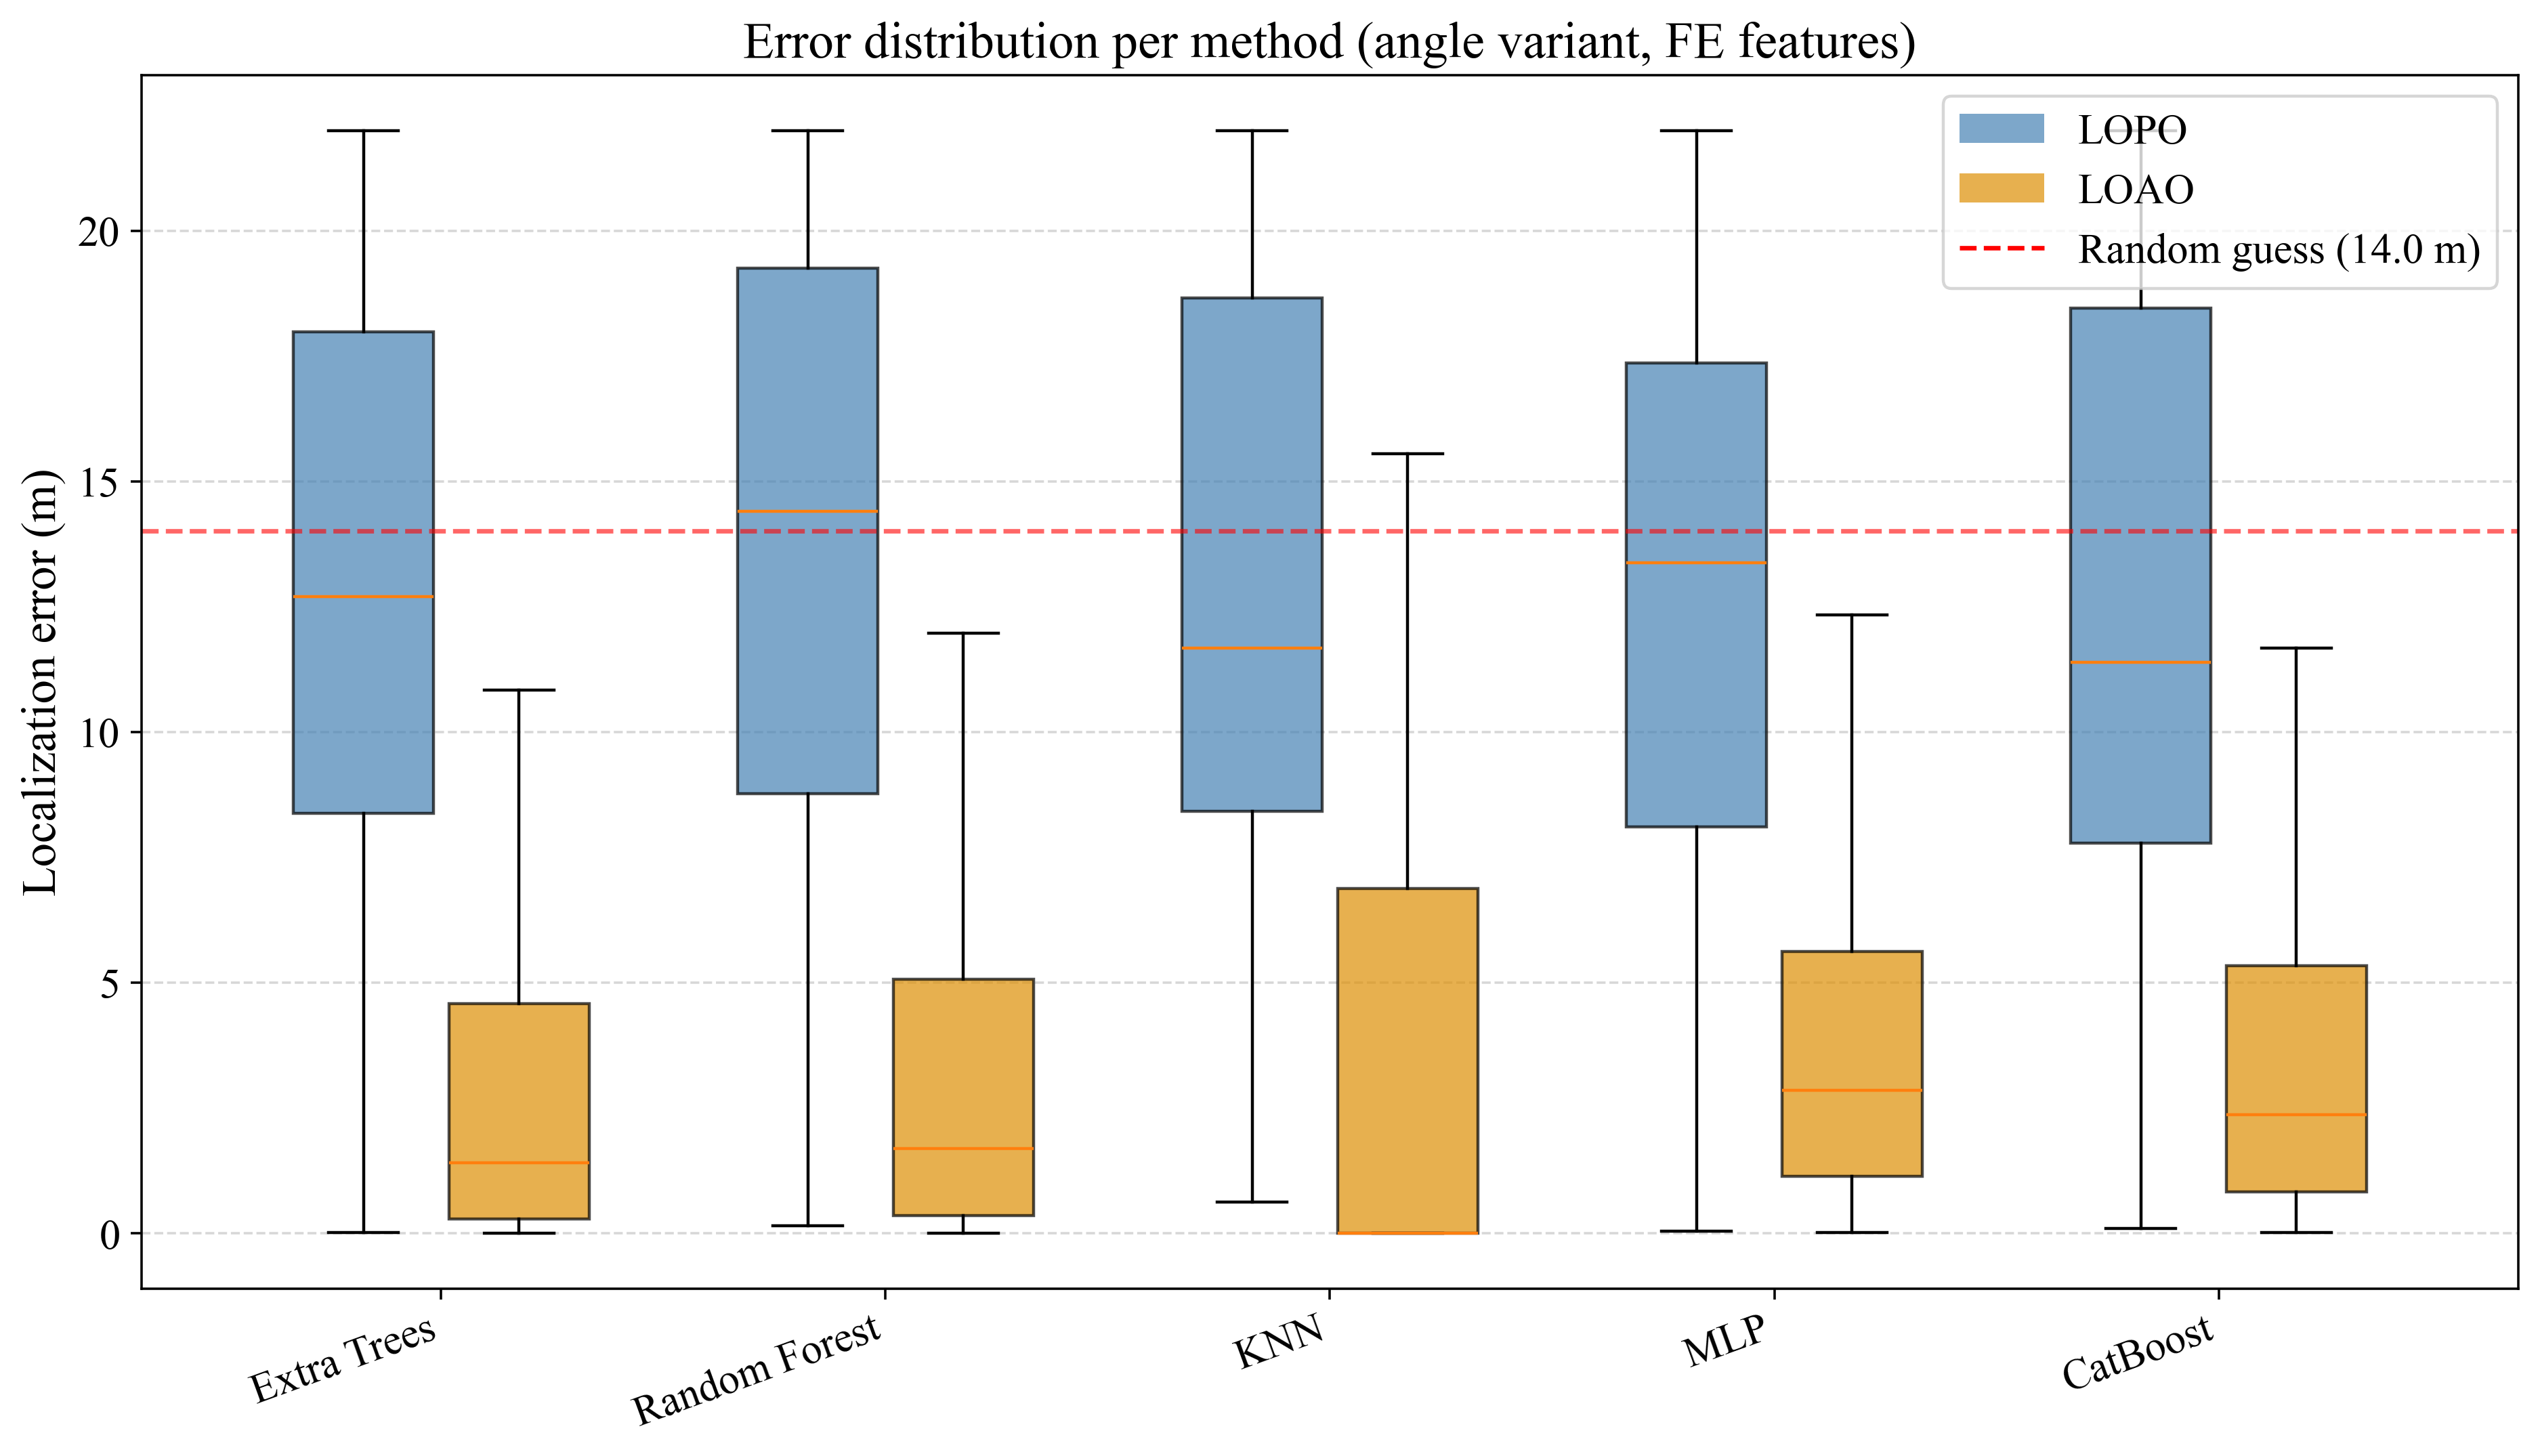

In [8]:
def _plot_localization_error(paper: bool):
    fig, ax = plt.subplots(figsize=(12, 7))
    models = list(ep.REGRESSOR_CONFIGS.keys())
    data, positions, colors, labels = [], [], [], []
    width = 0.35
    for i, model_name in enumerate(models):
        for offset, protocol, color in [(-1, "LOPO", "#4682B4"), (1, "LOAO", "#DE8F05")]:
            res = regression_oof[(model_name, "angle", protocol, "FE (13)")]
            data.append(res["oof_errors_m"])
            positions.append(i + offset * width / 2)
            colors.append(color)
    bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(ep.RANDOM_GUESS_ERROR_M, color="red", linestyle="--", alpha=0.6, label=f"Random guess ({ep.RANDOM_GUESS_ERROR_M:.1f} m)")
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha="right")
    ax.set_ylabel("Localization error (m)")
    if not paper:
        ax.set_title("Error distribution per method (angle variant, FE features)")
    from matplotlib.patches import Patch
    handles = [Patch(facecolor="#4682B4", alpha=0.7, label="LOPO"), Patch(facecolor="#DE8F05", alpha=0.7, label="LOAO"),
               plt.Line2D([0], [0], color="red", linestyle="--", label=f"Random guess ({ep.RANDOM_GUESS_ERROR_M:.1f} m)")]
    ax.legend(handles=handles)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    return fig

fig_internal = _plot_localization_error(paper=False)
fig_internal.savefig(INTERNAL_FIGURES_DIR / "localization_error.png", bbox_inches="tight")
plt.show()

fig_paper = _plot_localization_error(paper=True)
fig_paper.savefig(FIGURES_DIR / "localization_error.png", bbox_inches="tight")
plt.close(fig_paper)

## Fig: True vs. Predicted Positions — Best LOPO Model

The model/feature-set combination with the lowest mean LOPO error (angle variant),
plotted on the plane with the AP, sensors, and the 8 ring positions marked.

Best LOPO model: MLP (Base (4)) — mean error 11.57 m


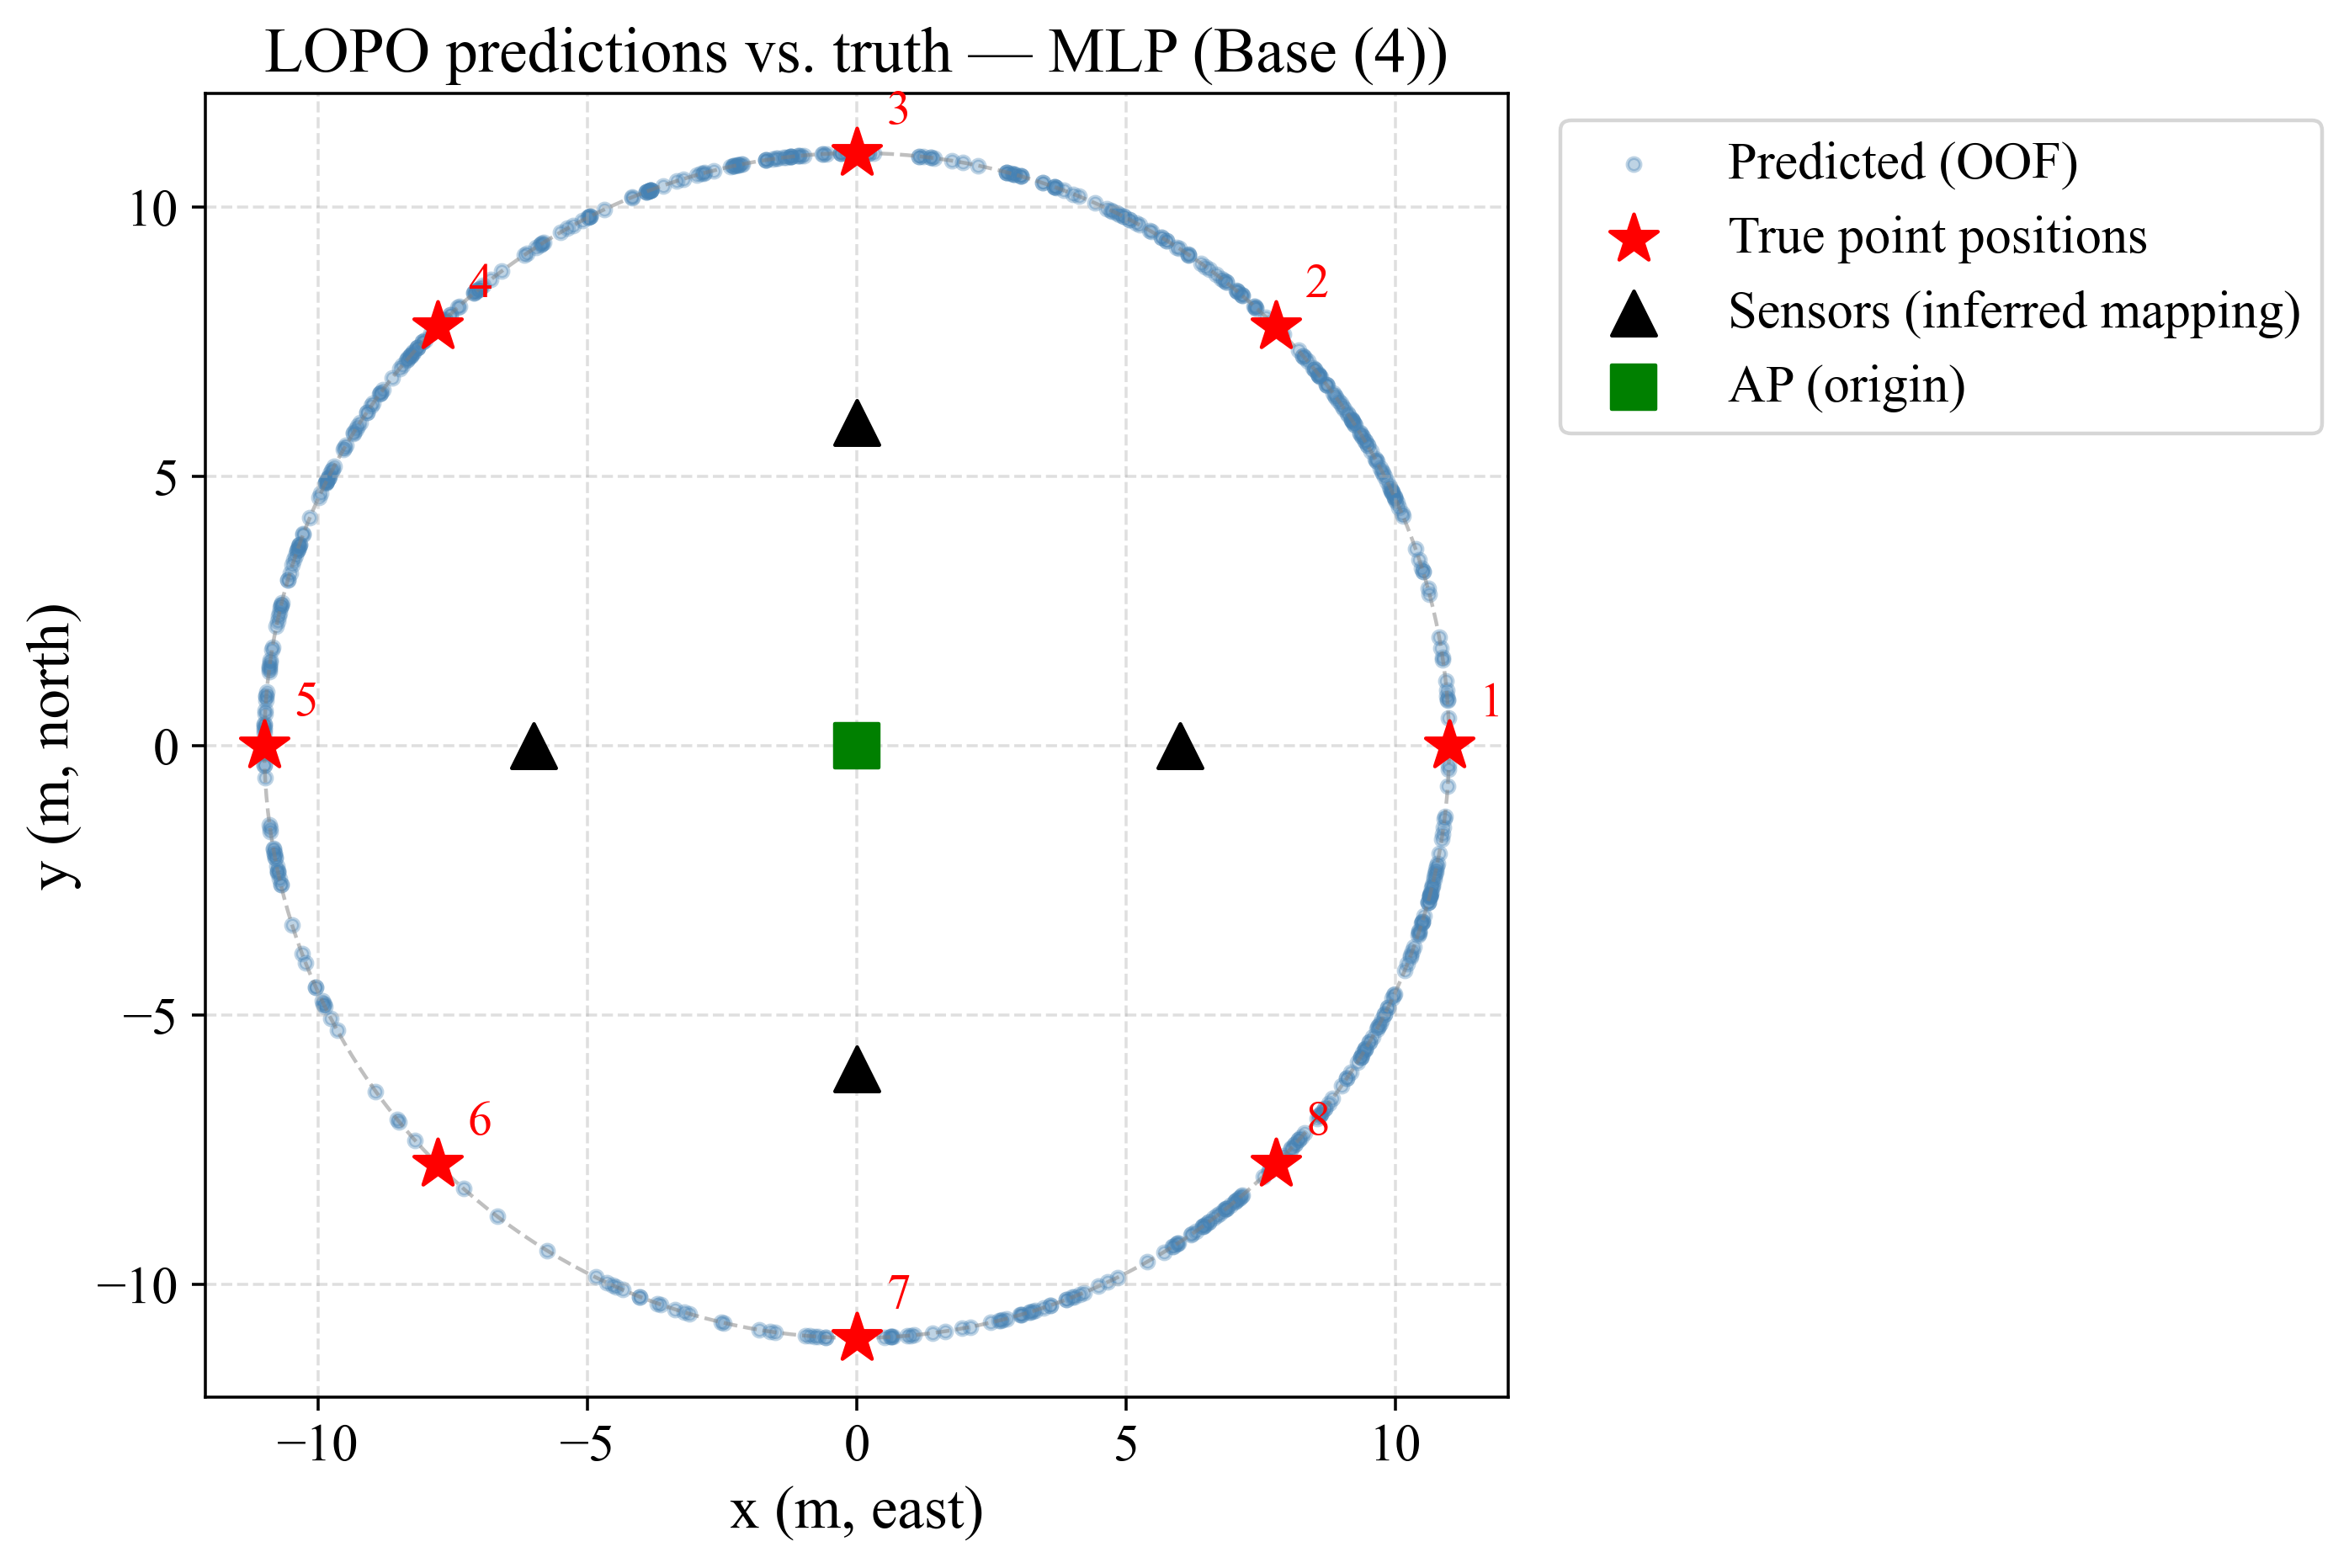

In [9]:
lopo_candidates = regression_df[(regression_df.protocol == "LOPO") & (regression_df.variant == "angle")]
best_row = lopo_candidates.loc[lopo_candidates["mean_error_m"].idxmin()]
best_model, best_fs = best_row["model"], best_row["feature_set"]
best_res = regression_oof[(best_model, "angle", "LOPO", best_fs)]
print(f"Best LOPO model: {best_model} ({best_fs}) — mean error {best_row['mean_error_m']:.2f} m")

def _plot_lopo_predictions(paper: bool):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.scatter(best_res["oof_pred_xy"][:, 0], best_res["oof_pred_xy"][:, 1], s=12, alpha=0.35, color="#4682B4", label="Predicted (OOF)")
    true_pts = np.array([ep.point_xy_m(i) for i in range(1, 9)])
    ax.scatter(true_pts[:, 0], true_pts[:, 1], s=180, marker="*", color="red", zorder=5, label="True point positions")
    for i, (x, y) in enumerate(true_pts, start=1):
        ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(8, 8), fontsize=13, color="red")
    sensor_xy = np.array(list(ep.SENSOR_POSITIONS.values()))
    ax.scatter(sensor_xy[:, 0], sensor_xy[:, 1], s=140, marker="^", color="black", zorder=5, label="Sensors (inferred mapping)")
    ax.scatter([0], [0], s=140, marker="s", color="green", zorder=5, label="AP (origin)")
    circle = plt.Circle((0, 0), ep.POINT_RADIUS_M, fill=False, linestyle="--", color="gray", alpha=0.5)
    ax.add_patch(circle)
    ax.set_xlabel("x (m, east)")
    ax.set_ylabel("y (m, north)")
    ax.set_aspect("equal")
    if not paper:
        ax.set_title(f"LOPO predictions vs. truth — {best_model} ({best_fs})")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    return fig

fig_internal = _plot_lopo_predictions(paper=False)
fig_internal.savefig(INTERNAL_FIGURES_DIR / "lopo_predictions.png", bbox_inches="tight")
plt.show()

fig_paper = _plot_lopo_predictions(paper=True)
fig_paper.savefig(FIGURES_DIR / "lopo_predictions.png", bbox_inches="tight")
plt.close(fig_paper)

## 5. R2.2 — Localization Baselines

(a) **Nearest centroid** (classification baseline: FE-feature class centroids,
standardized; under LOPO it can only return a *training* point, so its error is
bounded below by the adjacent-point chord, 8.42 m).
(b) **WCL** (weighted centroid localization, training-free, `SENSOR_POSITIONS`-dependent
— inferred from data, see section 3): raw estimate and its projection onto the R=11m
ring.
(c) **Log-distance trilateration** (`SENSOR_POSITIONS`-dependent — inferred from data):
path-loss exponent n fit per outer fold by grid search on the training rows, plus a
fixed n=2.0 variant.
(d) **KNN fingerprinting** — the existing point classifier (`nested_cv` with
`model_name="KNN"`), reinterpreted in metres.

All four under LOPO and LOAO, FE features, same metrics as R2.1.

In [10]:
baseline_rows = []
baseline_oof = {}

for protocol in PROTOCOLS_R21:
    outer_cv, groups = ep.get_regression_outer_cv_and_groups(protocol, sub)
    X_fe = sub[ep.FEATURES_FE]

    # (a) nearest centroid
    t0 = time.time()
    res_a = ep.nearest_centroid_oof(X_fe, y_point, groups, outer_cv)
    baseline_oof[("a_nearest_centroid", protocol)] = {"oof_true_xy": y_xy, "oof_pred_xy": res_a["oof_pred_xy"]}
    print(f"[{protocol}] (a) nearest centroid ({time.time()-t0:.1f}s)")

    # (b) WCL raw + projected (training-free, same for every protocol, but grouped identically here for CI-by-protocol bookkeeping)
    xy_raw = ep.wcl_predict_xy(sub, sensor_cols=ep.FEATURES_BASE, project_to_ring=False)
    xy_proj = ep.wcl_predict_xy(sub, sensor_cols=ep.FEATURES_BASE, project_to_ring=True)
    baseline_oof[("b_wcl_raw", protocol)] = {"oof_true_xy": y_xy, "oof_pred_xy": xy_raw}
    baseline_oof[("b_wcl_projected", protocol)] = {"oof_true_xy": y_xy, "oof_pred_xy": xy_proj}

    # (c) trilateration: fit n per outer fold, and fixed n=2.0
    t0 = time.time()
    res_c_fit = ep.trilateration_oof(sub, y_xy, groups, outer_cv, fit_n=True)
    baseline_oof[("c_trilateration_fit_n", protocol)] = res_c_fit
    res_c_fixed = ep.trilateration_oof(sub, y_xy, groups, outer_cv, fit_n=False, fixed_n=2.0)
    baseline_oof[("c_trilateration_n2.0", protocol)] = res_c_fixed
    print(f"[{protocol}] (c) trilateration: n_per_fold={[round(x,2) for x in res_c_fit['n_per_fold']]} ({time.time()-t0:.1f}s)")

    # (d) KNN fingerprinting (the existing classifier)
    t0 = time.time()
    res_d = ep.nested_cv(
        "KNN", X_fe, pd.Series(y_point), groups, outer_cv,
        ep.group_kfold_inner_factory(5), is_multiclass=True,
    )
    pred_xy_d = np.array([ep.point_xy_m(int(p)) for p in res_d["oof_pred"]])
    baseline_oof[("d_knn_fingerprint", protocol)] = {"oof_true_xy": y_xy, "oof_pred_xy": pred_xy_d}
    print(f"[{protocol}] (d) KNN fingerprint ({time.time()-t0:.1f}s)")

    for method_key, method_label in [
        ("a_nearest_centroid", "(a) Nearest centroid"),
        ("b_wcl_raw", "(b) WCL (raw)"),
        ("b_wcl_projected", "(b) WCL (projected to ring)"),
        ("c_trilateration_fit_n", "(c) Trilateration (n fit per fold)"),
        ("c_trilateration_n2.0", "(c) Trilateration (fixed n=2.0)"),
        ("d_knn_fingerprint", "(d) KNN fingerprinting"),
    ]:
        res = baseline_oof[(method_key, protocol)]
        summ = ep.regression_error_summary(np.sqrt(((res["oof_true_xy"] - res["oof_pred_xy"]) ** 2).sum(axis=1)))
        ci_mean = ep.xy_cluster_bootstrap_ci(res["oof_true_xy"], res["oof_pred_xy"], sessions, n_boot=2000, seed=0, metric="mean")
        sess_err, _ = ep.session_level_localization_error(res["oof_true_xy"], res["oof_pred_xy"], sessions)
        sess_summ = ep.regression_error_summary(sess_err)
        baseline_rows.append({
            "method": method_label, "protocol": protocol,
            "mean_error_m": summ["mean_error_m"], "median_error_m": summ["median_error_m"], "p90_error_m": summ["p90_error_m"],
            "ci_low_mean_m": ci_mean["ci_low"], "ci_high_mean_m": ci_mean["ci_high"],
            "session_mean_error_m": sess_summ["mean_error_m"], "session_median_error_m": sess_summ["median_error_m"],
            "n": summ["n"], "n_sessions": len(sess_err),
            "sensor_position_dependent": method_key.startswith(("b_", "c_")),
        })

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(RESULTS_DIR / "localization_baselines.csv", index=False)
baseline_df.round(3)

[LOPO] (a) nearest centroid (0.0s)


[LOPO] (c) trilateration: n_per_fold=[2.5, 2.5, 1.5, 2.5, 2.5, 2.4, 2.5, 2.5] (4.5s)


[LOPO] (d) KNN fingerprint (3.5s)


[LOAO] (a) nearest centroid (0.0s)


[LOAO] (c) trilateration: n_per_fold=[2.5, 2.5, 2.3, 2.5, 2.5, 2.5] (2.7s)


[LOAO] (d) KNN fingerprint (2.6s)


,method,protocol,mean_error_m,median_error_m,p90_error_m,ci_low_mean_m,ci_high_mean_m,session_mean_error_m,session_median_error_m,n,n_sessions,sensor_position_dependent
0,(a) Nearest centroid,LOPO,13.025,8.419,22.000,11.877,14.190,11.547,9.802,571,48,False
1,(b) WCL (raw),LOPO,10.056,10.269,13.125,9.481,10.623,9.995,10.374,571,48,True
2,(b) WCL (projected to ring),LOPO,10.281,9.641,20.721,8.510,12.109,9.301,8.337,571,48,True
3,(c) Trilateration (n fit per fold),LOPO,10.990,10.444,19.044,9.634,12.333,10.039,10.265,571,48,True
4,(c) Trilateration (fixed n=2.0),LOPO,10.597,10.699,16.757,9.390,11.839,9.817,10.415,571,48,True
5,(d) KNN fingerprinting,LOPO,13.126,8.419,22.000,12.052,14.207,11.542,10.401,571,48,False
6,(a) Nearest centroid,LOAO,3.719,0.000,15.556,2.577,4.809,3.203,1.997,571,48,False
7,(b) WCL (raw),LOAO,10.056,10.269,13.125,9.481,10.623,9.995,10.374,571,48,True
8,(b) WCL (projected to ring),LOAO,10.281,9.641,20.721,8.510,12.109,9.301,8.337,571,48,True
9,(c) Trilateration (n fit per fold),LOAO,10.458,10.470,17.321,9.294,11.636,9.639,10.433,571,48,True


## 6. Acceptance Check #1 — LOPO Held-Out Point Never in Training

Spot-check on top of the assertions already inside `nested_cv_regression` /
`nearest_centroid_oof` / `trilateration_oof` (every outer *and* inner split): rebuild the
LOPO splits directly and confirm the held-out point's rows never appear in the
corresponding training indices, for both the outer split and a representative inner
split.

In [11]:
outer_cv_lopo, groups_lopo = ep.get_regression_outer_cv_and_groups("LOPO", sub)
X_fe = sub[ep.FEATURES_FE]

violations = 0
for train_idx, test_idx in outer_cv_lopo.split(X_fe, y_xy, groups_lopo):
    held_out_points = set(np.unique(groups_lopo[test_idx]))
    train_points = set(np.unique(groups_lopo[train_idx]))
    if held_out_points & train_points:
        violations += 1
    inner_cv = ep.group_kfold_inner_factory(5)(groups_lopo[train_idx])
    for in_tr, in_te in inner_cv.split(X_fe.iloc[train_idx], y_xy[train_idx], groups_lopo[train_idx]):
        g_train_fold = groups_lopo[train_idx]
        if set(np.unique(g_train_fold[in_te])) & set(np.unique(g_train_fold[in_tr])):
            violations += 1

assert violations == 0, f"{violations} LOPO group-overlap violations found"
print(f"Checked {outer_cv_lopo.get_n_splits(groups=groups_lopo)} outer LOPO folds (+ inner splits): "
      f"the held-out point never appears in training. Violations: {violations}")

Checked 8 outer LOPO folds (+ inner splits): the held-out point never appears in training. Violations: 0
